HW1013
(1) Ch12_Q10 in p.555 (PCA)
In this problem, you will generate simulated data, and then perform PCA and K-means clustering on the data.

(a) Generate a simulated data set with 20 observations in each of three classes (i.e. 60 observations total), and 50 variables.
Hint: There are a number of functions in Python that you can use to generate data. One example is the normal() method of the random() function in numpy; the uniform() method is another option. Be sure to add a mean shift to the observations in each class so that there are three distinct classes.

In [65]:
import numpy as np
import pandas as pd

# Set the random seed for reproducibility
np.random.seed(1)

# Define the number of observations per class and the total number of variables
n_per_class = 20
n_classes = 3
n_variables = 50
total_observations = n_per_class * n_classes

# Define the mean shifts for each class
mean_shift = [0, 5, 10] # mean shift

# Initialize an empty data array
data = np.zeros((total_observations, n_variables))
labels = np.zeros(total_observations)  # Create a labels array

# Generate the data for each class
for i in range(n_classes):
    start_index = i * n_per_class
    end_index = (i + 1) * n_per_class

    # Generate data with a mean shift
    data[start_index:end_index, :] = np.random.normal(loc=mean_shift[i], scale=1, size=(n_per_class, n_variables)) #the normal() method of the random() 

    # Assign labels to each class
    labels[start_index:end_index] = i

# Convert data and labels to pandas DataFrames (optional, but often helpful)
data_df = pd.DataFrame(data)
labels_df = pd.Series(labels, name='Class')

print("Data shape:", data_df.shape)
print("Labels shape:", labels_df.shape)

Data shape: (60, 50)
Labels shape: (60,)


In [37]:
data_df.head()

,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
0,1.624345,-0.611756,-0.528172,-1.072969,0.865408,-2.301539,1.744812,-0.761207,0.319039,-0.249370,...,-0.191836,-0.887629,-0.747158,1.692455,0.050808,-0.636996,0.190915,2.100255,0.120159,0.617203
1,0.300170,-0.352250,-1.142518,-0.349343,-0.208894,0.586623,0.838983,0.931102,0.285587,0.885141,...,1.198918,0.185156,-0.375285,-0.638730,0.423494,0.077340,-0.343854,0.043597,-0.620001,0.698032
2,-0.447129,1.224508,0.403492,0.593579,-1.094912,0.169382,0.740556,-0.953701,-0.266219,0.032615,...,-0.186570,-0.101746,0.868886,0.750412,0.529465,0.137701,0.077821,0.618380,0.232495,0.682551
3,-0.310117,-2.434838,1.038825,2.186980,0.441364,-0.100155,-0.136445,-0.119054,0.017409,-1.122019,...,1.160339,0.369493,1.904659,1.111057,0.659050,-1.627438,0.602319,0.420282,0.810952,1.044442
4,-0.400878,0.824006,-0.562305,1.954878,-1.331952,-1.760689,-1.650721,-0.890556,-1.119115,1.956079,...,-0.498214,-0.310985,-0.001891,-1.396620,-0.861316,0.674712,0.618539,-0.443172,1.810535,-1.305727


(b) Perform PCA on the 60 observations and plot the first two principal component score vectors. Use a different color to indicate the observations in each of the three classes. If the three classes appear separated in this plot, then continue on to part (c). If not, then return to part (a) and modify the simulation so that there is greater separation between the three classes. Do not continue to part (c) until the three classes show at least some separation in the first two principal component score vectors.

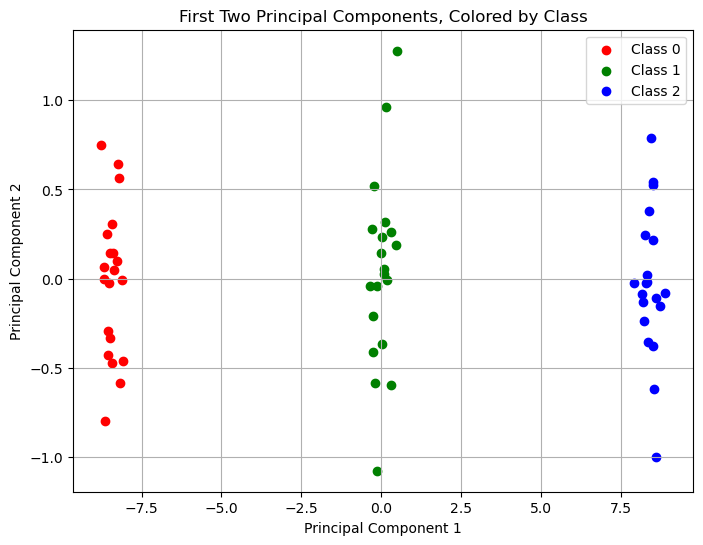

Explained variance ratio: [0.94570671 0.0039748 ]


In [67]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Standardize the data, PCA is very sensitive to the scale of the variables
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data_df)

# Perform PCA
pca = PCA(n_components=2)  # Project to 2 dimensions
principal_components = pca.fit_transform(scaled_data)

# Create a DataFrame for the principal components
pc_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])

# Add the labels to the principal component DataFrame
pc_df['Class'] = labels_df.values

# Plot the first two principal components, colored by class
plt.figure(figsize=(8, 6))
colors = ['r', 'g', 'b']  # Red, Green, Blue for the three classes
for i in range(n_classes):
    subset = pc_df[pc_df['Class'] == i]
    plt.scatter(subset['PC1'], subset['PC2'], c=colors[i], label=f'Class {i}')

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('First Two Principal Components, Colored by Class')
plt.legend()
plt.grid(True)
plt.show()

# Explained variance
print("Explained variance ratio:", pca.explained_variance_ratio_)
#A common rule of thumb is to retain enough components to explain at least 70-80% of the variance. component 1+2
# chagr the scale from 5 to 1 and the ratio improve a lots.

In [19]:
pc_df.shape

(60, 3)

(c) Perform K-means clustering of the observations with K = 3. How well do the clusters that you obtained in K-means clustering compare to the true class labels?
Hint: You can use the pd.crosstab() function in Python to compare the true class labels to the class labels obtained by clustering. Be careful how you interpret the results: K-means clustering will arbitrarily number the clusters, so you cannot simply check whether the true class labels and clustering labels are the same.

In [141]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Perform K-means clustering
kmeans = KMeans(n_clusters=3, n_init=10, random_state=1)  # n_init avoids warnings, random_state for reproducibility
cluster_labels = kmeans.fit_predict(data) #with row data

# Evaluate K-means clustering
# Create a cross-tabulation (confusion matrix)
cross_tab = pd.crosstab(labels_df, cluster_labels, rownames=['True Class'], colnames=['K-means Cluster'])
print(cross_tab)

silhouette_avg = silhouette_score(scaled_data, cluster_labels)
print(f"Silhouette Score: {silhouette_avg}")

# Interpretation:
# The cross-tab shows how many observations from each true class were assigned to each K-means cluster.
# The Silhouette Score provides a measure of how well each observation fits into its assigned cluster, ranging from -1 to 1. 
# Higher values indicate better clustering.

K-means Cluster   0   1   2
True Class                 
0.0               0  20   0
1.0              20   0   0
2.0               0   0  20
Silhouette Score: 0.7257202845915784


(d) Perform K-means clustering with K = 2. Describe your results.

In [139]:
# Perform K-means clustering K=2
kmeans = KMeans(n_clusters=2, n_init=10, random_state=1)  # n_init avoids warnings, random_state for reproducibility
cluster_labels = kmeans.fit_predict(data) #with row data

# Evaluate K-means clustering
# Create a cross-tabulation (confusion matrix)
cross_tab = pd.crosstab(labels_df, cluster_labels, rownames=['True Class'], colnames=['K-means Cluster'])
print(cross_tab)

silhouette_avg = silhouette_score(scaled_data, cluster_labels)
print(f"Silhouette Score: {silhouette_avg}")

K-means Cluster   0   1
True Class             
0.0               0  20
1.0              20   0
2.0              20   0
Silhouette Score: 0.6138388073125343


(e) Now perform K-means clustering with K = 4, and describe your
results.

In [137]:
# Perform K-means clustering K=4
kmeans = KMeans(n_clusters=4, n_init=10, random_state=1)  # n_init avoids warnings, random_state for reproducibility
cluster_labels = kmeans.fit_predict(data) #with row data

# Evaluate K-means clustering
# Create a cross-tabulation (confusion matrix)
cross_tab = pd.crosstab(labels_df, cluster_labels, rownames=['True Class'], colnames=['K-means Cluster'])
print(cross_tab)

silhouette_avg = silhouette_score(scaled_data, cluster_labels)
print(f"Silhouette Score: {silhouette_avg}")

K-means Cluster   0   1   2  3
True Class                    
0.0              20   0   0  0
1.0               0   0  13  7
2.0               0  20   0  0
Silhouette Score: 0.4996385164157059


(f) Now perform K-means clustering with K = 3 on the first two principal component score vectors, rather than on the raw data. That is, perform K-means clustering on the 60 × 2 matrix of which the first column is the first principal component score vector, and the second column is the second principal component score vector. Comment on the results.

K-means Cluster   0   1   2
True Class                 
0.0               0  20   0
1.0              20   0   0
2.0               0   0  20
Silhouette Score: 0.7257202845915784


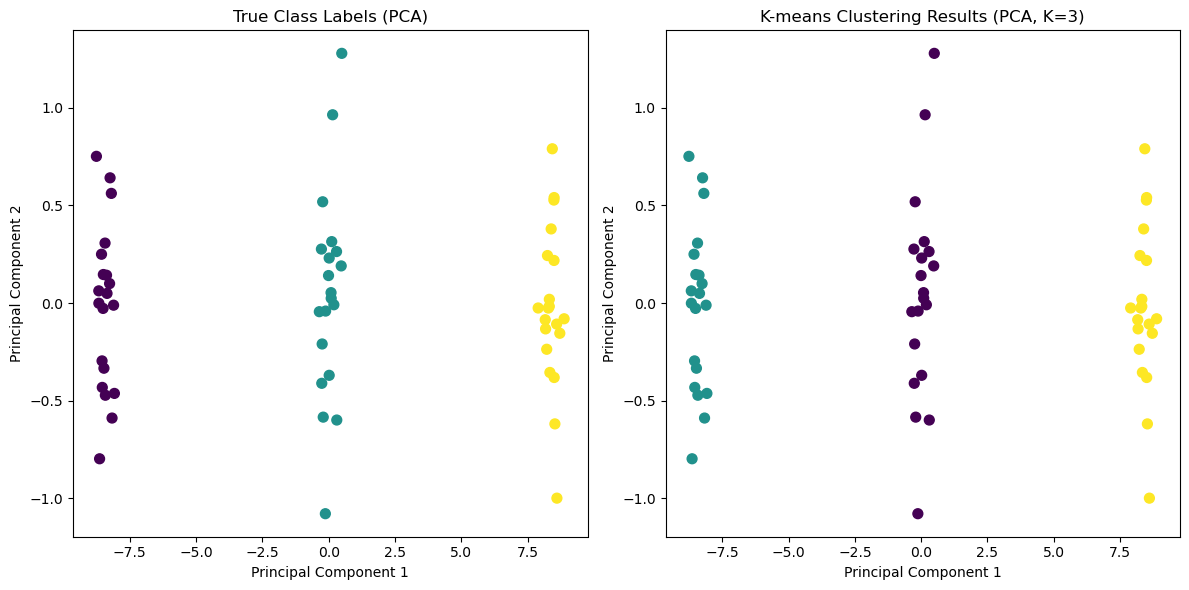

In [121]:
# Perform K-means clustering K=3
kmeans = KMeans(n_clusters=3, n_init=10, random_state=1)  # n_init avoids warnings, random_state for reproducibility
cluster_labels = kmeans.fit_predict(principal_components) #with 1+2 principal component score vector

# Evaluate K-means clustering
# Create a cross-tabulation (confusion matrix)
cross_tab = pd.crosstab(labels_df, cluster_labels, rownames=['True Class'], colnames=['K-means Cluster'])
print(cross_tab)

silhouette_avg = silhouette_score(scaled_data, cluster_labels)
print(f"Silhouette Score: {silhouette_avg}")

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.scatter(principal_components[:, 0], principal_components[:, 1], c=labels_df, cmap='viridis', s=50)
plt.title("True Class Labels (PCA)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

# K-means 
plt.subplot(1, 2, 2)
plt.scatter(principal_components[:, 0], principal_components[:, 1], c=cluster_labels, cmap='viridis', s=50)
plt.title("K-means Clustering Results (PCA, K=3)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.tight_layout()
plt.show()

(g) Using the StandardScaler() estimator, perform K-means clustering with K = 3 on the data after scaling each variable to have standard deviation one. How do these results compare to those obtained in (b)? Explain.

In [135]:
# Perform K-means clustering K=3
kmeans = KMeans(n_clusters=3, n_init=10, random_state=1)  # n_init avoids warnings, random_state for reproducibility
cluster_labels = kmeans.fit_predict(scaled_data) #with scaled data

# Evaluate K-means clustering
# Create a cross-tabulation (confusion matrix)
cross_tab = pd.crosstab(labels_df, cluster_labels, rownames=['True Class'], colnames=['K-means Cluster'])
print(cross_tab)

silhouette_avg = silhouette_score(scaled_data, cluster_labels)
print(f"Silhouette Score: {silhouette_avg}")

K-means Cluster   0   1   2
True Class                 
0.0               0  20   0
1.0              20   0   0
2.0               0   0  20
Silhouette Score: 0.7257202845915784
